# Implicit Tilt Matching Explained (with connections to RAM)

This notebook explains
[**Tilt Matching for Scalable Sampling and Fine-Tuning**](https://arxiv.org/abs/2512.21829)
(Potaptchik, Lee, and Albergo, ICML 2026), focusing on **Implicit Tilt Matching
(ITM)**.

**The problem:** Given a pretrained sampler for $p_{\text{ref}}(x)$, learn to
sample from the reward-tilted target

$$
p_{\text{target}}(x)
\;\propto\;
p_{\text{ref}}(x)\,\exp(\beta r(x)),
$$

where $r(x)$ is a reward function and $\beta$ controls how strongly we tilt.
The sampler should prefer high-reward regions, without differentiating the
reward or backpropagating through sampler trajectories.

We will also connect ITM to
[**Reinforce Adjoint Matching (RAM)**](https://arxiv.org/abs/2605.10759),
another reward-based post-training method for flow models. The main conceptual
connection is simple: **RAM is the first-order Taylor approximation of ITM**.
ITM uses the full exponential coefficient $e^{\beta r}-1$, while RAM keeps only
the linear term $\beta r$. We will make this connection explicit before writing
code.

We will build a tiny 2D version from scratch:

1. pretrain a flow-matching model on an 8-mode ring with a smooth reward,
2. derive **ITM** using full exponential reweighting,
3. explain the connection to **RAM** (first-order approximation),
4. implement ITM with the same RAM-style training skeleton,
5. compare ITM, RAM, and **WFM** using mean reward and sliced Wasserstein,
6. run a $\beta$ sweep to see when the methods differ.

If you already read our
[RAM tutorial](https://xing-mei.github.io/notes/ram-tutorial.html), this
notebook lives in the same world. We did not find official ITM code, so the
implementation here is an educational reconstruction from the paper and this
derivation, not a reproduction of the authors' experimental code.

Edit History:
- 06-17-2026: initial version

## 0. Setup

We use only `torch`, `numpy`, `matplotlib`, and `tqdm`. Everything runs on CPU.
The toy is intentionally small: 2D points, a small MLP, and simple Euler
sampling.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import Markdown, display

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device("cpu")
torch.set_default_dtype(torch.float32)
SHOW_PROGRESS = False


def display_markdown_table(headers, rows):
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    lines.extend("| " + " | ".join(str(x) for x in row) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

print("torch:", torch.__version__)

torch: 2.11.0


We first define all plotting, density, and sampling helpers. Keeping them in
one place makes the later sections read like the math.

In [2]:
def plot_samples(
    samples,
    ax=None,
    *,
    title=None,
    color="C0",
    s=6,
    alpha=0.4,
    xlim=(-5, 5),
    ylim=(-5, 5),
    c=None,
    cmap=None,
    label=None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    pts = samples.detach().cpu().numpy()
    if c is None:
        ax.scatter(pts[:, 0], pts[:, 1], s=s, alpha=alpha, color=color, label=label)
    else:
        ax.scatter(pts[:, 0], pts[:, 1], s=s, alpha=alpha, c=c, cmap=cmap, label=label)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)
    return ax


def make_grid(n_grid=75, xlim=(-5, 5), ylim=(-5, 5)):
    gx = torch.linspace(xlim[0], xlim[1], n_grid)
    gy = torch.linspace(ylim[0], ylim[1], n_grid)
    X, Y = torch.meshgrid(gx, gy, indexing="ij")
    pts = torch.stack([X.flatten(), Y.flatten()], dim=-1)
    return pts, X, Y


def kde_density(grid_pts, samples, h=0.16, chunk=2048):
    vals = []
    for part in grid_pts.split(chunk):
        d2 = ((part[:, None, :] - samples[None, :, :]) ** 2).sum(-1)
        vals.append(torch.exp(-0.5 * d2 / h**2).mean(-1))
    return torch.cat(vals, dim=0)


def normalize_density(z):
    return z / (z.sum() + 1e-12)


def plot_density(density_fn, ax=None, *, title=None, n_grid=75, cmap="viridis"):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    grid, X, Y = make_grid(n_grid=n_grid)
    Z = density_fn(grid).detach().cpu().reshape(n_grid, n_grid).numpy()
    ax.imshow(Z.T, origin="lower", extent=(-5, 5, -5, 5), cmap=cmap)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)
    return ax


def sample_source(n: int) -> torch.Tensor:
    return torch.randn(n, 2)


def ring_centers(modes: int = 8, radius: float = 4.0):
    angles = torch.arange(modes) * (2 * math.pi / modes)
    return torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=-1)


def sample_ring(
    n: int,
    modes: int = 8,
    radius: float = 4.0,
    sigma: float = 0.15,
    return_labels: bool = False,
):
    labels = torch.randint(0, modes, (n,))
    centers = ring_centers(modes, radius)[labels]
    samples = centers + sigma * torch.randn(n, 2)
    if return_labels:
        return samples, labels
    return samples


def assign_ring_modes(x: torch.Tensor):
    centers = ring_centers().to(x)
    d2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
    return d2.argmin(-1)

## 1. The target: tilt a sampler toward reward

We will use the same kind of toy as the RAM tutorial: an 8-mode Gaussian ring.
The pretrained model should generate all ring modes. The reward will prefer
the right-most mode near $(4,0)$.

Why this toy works well:

* It is 2D, so every distribution can be plotted.
* It is multi-modal, so "just move the mean" is not enough.
* The reward-tilted target can be visualized directly:

$$
p_{\mathrm{target}}(x)
\;\propto\;
p_{\mathrm{ref}}(x)\exp(\beta r(x)).
$$

Here $p_{\mathrm{ref}}$ is what our pretrained flow actually samples, not the
ideal ring density. This matches the post-training situation: start from the
model you have, then tilt it.

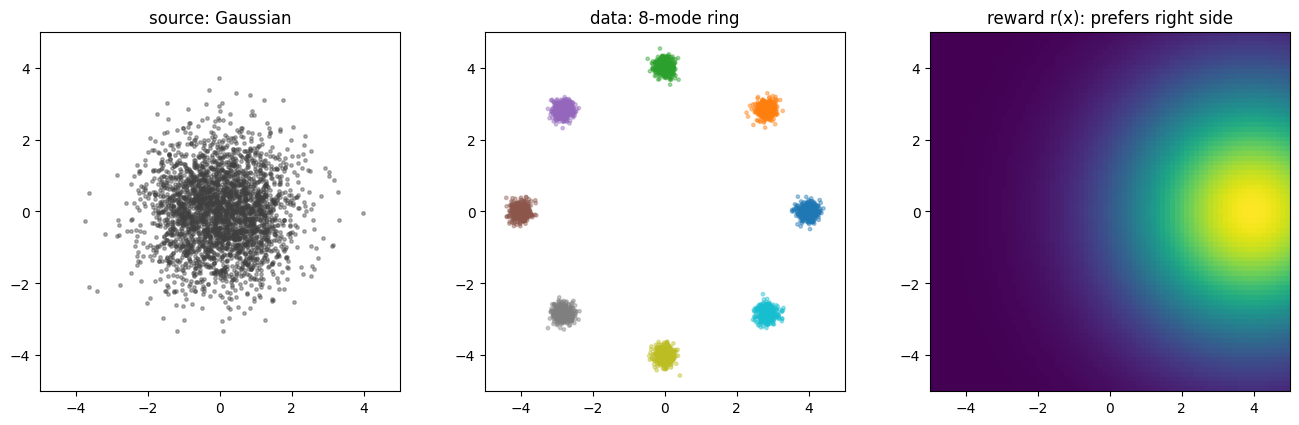

In [3]:
def reward(x: torch.Tensor, center=(4.0, 0.0), scale: float = 2.5) -> torch.Tensor:
    c = torch.as_tensor(center, dtype=x.dtype, device=x.device)
    return torch.exp(-0.5 * ((x - c) ** 2).sum(-1) / scale**2)


BETA = 5.0


def tilted_reward(x: torch.Tensor) -> torch.Tensor:
    return BETA * reward(x)


ring_samples, ring_labels = sample_ring(3000, return_labels=True)
src_samples = sample_source(3000)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
plot_samples(src_samples, axes[0], title="source: Gaussian", color="0.25")
plot_samples(ring_samples, axes[1], title="data: 8-mode ring", c=ring_labels.numpy(), cmap="tab10")
plot_density(reward, axes[2], title="reward r(x): prefers right side")
plt.tight_layout()
plt.show()

## 2. Stage 1: train a reference flow

Before post-training, we need a base sampler. We use the same time convention
as the RAM tutorial:

* $t=0$: clean data / final generated sample,
* $t=1$: Gaussian noise / source sample.

The Tilt Matching paper writes the opposite orientation, with the target at
$t=1$. Nothing mathematical changes, but this notebook uses the RAM-style
notation $v_\theta$ and $X_t$ so the comparison with RAM is easier to read.

We also copy the RAM tutorial's Stage-1 toy setup: the same 8-mode ring
sharpness, the same small velocity MLP, the same 5000-step flow-matching
pretraining, and the same 50-step Euler sampler.

The linear stochastic interpolant is

$$
X_t = (1-t)X_0 + t\varepsilon,
\qquad
X_0\sim p_{\mathrm{data}},
\quad
\varepsilon\sim \mathcal{N}(0,I).
$$

At $t=0$, the point is data. At $t=1$, it is Gaussian noise. The velocity
of this straight-line path is

$$
\dot X_t = \varepsilon - X_0.
$$

Flow matching trains a neural velocity field $v_\theta(x,t)$ by ordinary
regression:

$$
\mathcal{L}_{\mathrm{FM}}(\theta)
=
\mathbb{E}
\left[
\|v_\theta(X_t,t) - (\varepsilon-X_0)\|^2
\right].
$$

The model predicts the velocity from data toward noise as $t$ increases. To
generate, we draw $\varepsilon\sim\mathcal{N}(0,I)$ at $t=1$ and integrate the
ODE **backward** to $t=0$.

In [4]:
class VelocityNet(nn.Module):
    def __init__(self, hidden: int = 128, n_freqs: int = 8):
        super().__init__()
        self.register_buffer("freqs", 2 ** torch.arange(n_freqs).float() * math.pi)
        in_dim = 2 + 2 * n_freqs
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def time_emb(self, t: torch.Tensor) -> torch.Tensor:
        angles = t[:, None] * self.freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x, self.time_emb(t)], dim=-1))


def num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


@torch.no_grad()
def sample_flow(model: VelocityNet, n: int, n_steps: int = 50) -> torch.Tensor:
    model.eval()
    x = sample_source(n)
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((n,), 1.0 - k * dt)
        x = x - model(x, t) * dt
    return x


def pretrain_flow_matching(
    model: VelocityNet,
    *,
    steps: int = 5000,
    batch_size: int = 256,
    lr: float = 1e-3,
) -> list[float]:
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    pbar = tqdm(range(steps), desc="pretrain", mininterval=2.0, disable=not SHOW_PROGRESS, leave=False)
    for step in pbar:
        x0 = sample_ring(batch_size)
        eps = sample_source(batch_size)
        t = torch.rand(batch_size)
        xt = (1 - t[:, None]) * x0 + t[:, None] * eps
        target = eps - x0
        pred = model(xt, t)
        loss = ((pred - target) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if step % 500 == 0:
            pbar.set_postfix(loss=f"{loss.item():.3f}")
    return losses


v_ref = VelocityNet()
print(f"VelocityNet parameters: {num_params(v_ref):,}")
pretrain_losses = pretrain_flow_matching(v_ref)
v_ref.eval()
for p in v_ref.parameters():
    p.requires_grad_(False)

VelocityNet parameters: 35,714


mean reward of pretrained samples: 0.271


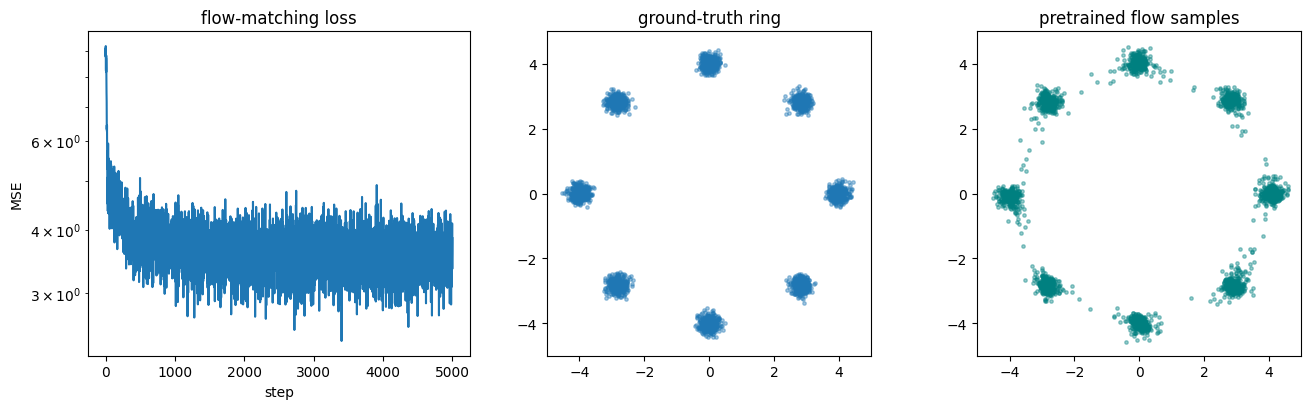

In [5]:
ref_samples = sample_flow(v_ref, 3000)
ref_reward = reward(ref_samples).mean().item()
print(f"mean reward of pretrained samples: {ref_reward:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
axes[0].plot(pretrain_losses)
axes[0].set_title("flow-matching loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
plot_samples(sample_ring(3000), axes[1], title="ground-truth ring", color="C0")
plot_samples(ref_samples, axes[2], title="pretrained flow samples", color="teal")
plt.tight_layout()
plt.show()

The pretrained flow is our $p_{\mathrm{ref}}$. We will now tilt **this**
model, not the unknown ideal data distribution.

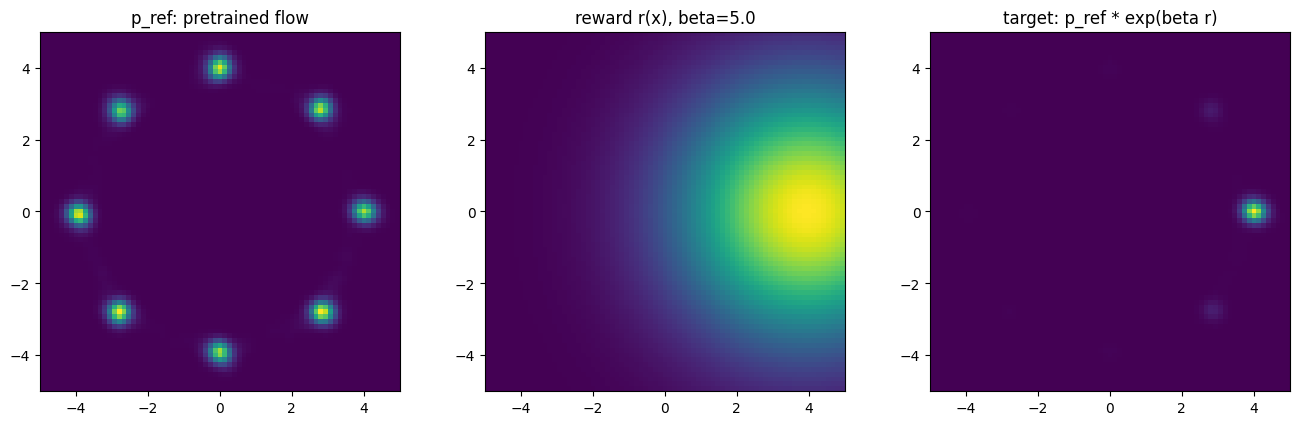

In [6]:
ref_big = sample_flow(v_ref, 4000)


def p_ref_density(grid_pts):
    return normalize_density(kde_density(grid_pts, ref_big, h=0.16))


def p_target_density(grid_pts):
    p = kde_density(grid_pts, ref_big, h=0.16) * torch.exp(tilted_reward(grid_pts))
    return normalize_density(p)


fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
plot_density(p_ref_density, axes[0], title="p_ref: pretrained flow")
plot_density(reward, axes[1], title=f"reward r(x), beta={BETA}")
plot_density(p_target_density, axes[2], title="target: p_ref * exp(beta r)")
plt.tight_layout()
plt.show()

## 3. Implicit Tilt Matching (ITM)

We have a pretrained reference model that samples from $p_{\text{ref}}$. We want to sample from:

$$
p_{\text{target}}(x) \propto p_{\text{ref}}(x) e^{\beta r(x)}.
$$

**Core idea:** Reweight velocity samples using $e^{\beta r}$.

### The reweighting formula

In flow matching, $X_0$ means the clean endpoint at time $t=0$. In Stage-1
pretraining, those endpoints came from the data distribution $p_{\text{data}}$.
After pretraining, however, ITM fine-tunes the frozen sampler's own distribution:
$X_0 \sim p_{\text{ref}}$. Then sample
noise $\varepsilon \sim \mathcal{N}(0,I)$, then interpolate:

$$
X_t = (1-t)X_0 + t\varepsilon,
\qquad t \in [0,1].
$$

The velocity is $\varepsilon - X_0$. 

**The bucket perspective:** Fix a location $x$ and time $t$. Think of all
possible pairs $(X_0, \varepsilon)$ that land at $X_t = x$ — these form a
"bucket." The pretrained velocity is the probability-weighted average over this
bucket:

$$
v_{\text{ref}}(x, t)
=
\frac{
\int (\varepsilon - X_0) \, p_{\text{ref}}(X_0) \varphi(\varepsilon) \,
\delta(x - (1-t)X_0 - t\varepsilon) \, dX_0 \, d\varepsilon
}{
\int p_{\text{ref}}(X_0) \varphi(\varepsilon) \,
\delta(x - (1-t)X_0 - t\varepsilon) \, dX_0 \, d\varepsilon
},
$$

where $\varphi(\varepsilon)$ is the Gaussian noise density and $\delta(\cdot)$
enforces the constraint that $(X_0, \varepsilon)$ land at $x$. This is shorthand
for:

$$
v_{\text{ref}}(x, t) = \mathbb{E}_{p_{\text{ref}}}[\varepsilon - X_0 \mid X_t = x].
$$

For the tilted target, we want:

$$
v_{\text{target}}(x, t) = \mathbb{E}_{p_{\text{target}}}[\varepsilon - X_0 \mid X_t = x].
$$

**Key observation:** When moving from $p_{\text{ref}}$ to
$p_{\text{target}} \propto p_{\text{ref}} e^{\beta r}$,
the bucket at $(x, t)$ doesn't change — the same pairs $(X_0, \varepsilon)$ still
land at $X_t = x$. The noise distribution $\varphi(\varepsilon)$ stays the same,
and the constraint $\delta(x - (1-t)X_0 - t\varepsilon)$ stays the same.

**Only the endpoint probability changes:**

$$
p_{\text{ref}}(X_0)
\quad\longrightarrow\quad
p_{\text{target}}(X_0)
\propto
p_{\text{ref}}(X_0)e^{\beta r(X_0)}.
$$

Therefore the tilted velocity is:

$$
v_{\text{target}}(x, t)
=
\frac{
\int (\varepsilon - X_0) \, e^{\beta r(X_0)} p_{\text{ref}}(X_0) \varphi(\varepsilon) \,
\delta(x - (1-t)X_0 - t\varepsilon) \, dX_0 \, d\varepsilon
}{
\int e^{\beta r(X_0)} p_{\text{ref}}(X_0) \varphi(\varepsilon) \,
\delta(x - (1-t)X_0 - t\varepsilon) \, dX_0 \, d\varepsilon
}.
$$

In shorthand:

$$
v_{\text{target}}(x, t)
=
\frac{\mathbb{E}_{p_{\text{ref}}}[(\varepsilon - X_0) \cdot e^{\beta r(X_0)} \mid X_t = x]}
{\mathbb{E}_{p_{\text{ref}}}[e^{\beta r(X_0)} \mid X_t = x]}.
$$

Inside the bucket at $(x, t)$, pairs leading to high-reward $X_0$ get weight
$e^{\beta r(X_0)}$ (large), while pairs leading to low-reward $X_0$ get weight
$e^{\beta r(X_0)}$ (small).

### Deriving the ITM target

Write $R = \beta r(X_0)$ for reward. From the weighted-average formula above,
the ideal tilted velocity satisfies:

$$
v_{\text{target}}(x,t)
=
\frac{\mathbb{E}_{p_{\text{ref}}}[e^R(\varepsilon-X_0)\mid X_t=x]}
{\mathbb{E}_{p_{\text{ref}}}[e^R\mid X_t=x]}.
$$

Multiply both sides by the denominator:

$$
\mathbb{E}_{p_{\text{ref}}}[e^R(\varepsilon-X_0)\mid X_t=x]
=
v_{\text{target}}(x,t)\,
\mathbb{E}_{p_{\text{ref}}}[e^R\mid X_t=x].
$$

Now comes a small but important trick. After we condition on $X_t=x$ and fix
$t$, the value $v_{\text{target}}(x,t)$ is just one vector number for this
bucket. It does **not** vary across the different pairs $(X_0,\varepsilon)$
inside the bucket. Therefore we can write:

$$
\mathbb{E}_{p_{\text{ref}}}[e^R (\varepsilon - X_0) \mid X_t = x] = \mathbb{E}_{p_{\text{ref}}}[e^R v_{\text{target}} \mid X_t = x].
$$

Use $e^R = 1 + (e^R - 1)$ to split:

$$
\mathbb{E}_{p_{\text{ref}}}[\varepsilon - X_0 \mid X_t=x] + \mathbb{E}_{p_{\text{ref}}}[(e^R - 1)(\varepsilon - X_0) \mid X_t=x]
= \mathbb{E}_{p_{\text{ref}}}[v_{\text{target}} \mid X_t=x] + \mathbb{E}_{p_{\text{ref}}}[(e^R - 1)v_{\text{target}} \mid X_t=x].
$$

Rearrange:

$$
\mathbb{E}_{p_{\text{ref}}}[v_{\text{target}} \mid X_t=x]
= \mathbb{E}_{p_{\text{ref}}}[\varepsilon - X_0 \mid X_t=x] + \mathbb{E}_{p_{\text{ref}}}[(e^R - 1)(\varepsilon - X_0 - v_{\text{target}}) \mid X_t=x].
$$

The first term is $v_{\text{ref}}(x, t)$. The second term is still an average
over all pairs in the bucket. In SGD, we do not enumerate the whole bucket;
each training example gives a **one-sample Monte Carlo estimate** of that
average:

$$
T^{\text{ideal}}(X_0,\varepsilon,t)
=
v_{\text{ref}}(X_t, t)
+ (e^R - 1)(\varepsilon - X_0 - v_{\text{target}}(X_t, t)).
$$

Conditioned on $X_t=x$, the expectation of this one-sample target is the exact
$v_{\text{target}}(x,t)$. But it is still a fixed-point target because
$v_{\text{target}}$ appears on the right-hand side. We don't know
$v_{\text{target}}$ yet — that's what we're trying to learn.

So the actual ITM training equation replaces the unknown $v_{\text{target}}$
on the right-hand side with the current neural network, but uses
**stop-gradient** there so the right-hand side acts like a regression target:

$$
\boxed{
\begin{aligned}
T_{\theta}^{\text{ITM}}(X_0,\varepsilon,t)
&=
v_{\text{ref}}(X_t,t)
+ \bigl(e^{\beta r(X_0)} - 1\bigr)
\left(
\varepsilon - X_0 - \operatorname{sg}\bigl(v_{\theta}(X_t,t)\bigr)
\right),
\\[4pt]
\mathcal{L}_{\text{ITM}}(\theta)
&=
\mathbb{E}_{X_0\sim p_{\text{ref}},\;\varepsilon,\;t}
\left[
\left\|
v_{\theta}(X_t,t) - T_{\theta}^{\text{ITM}}(X_0,\varepsilon,t)
\right\|^2
\right].
\end{aligned}
}
$$

This boxed equation is the core of ITM in this notebook.

**Summary:** Sample pairs from $p_{\text{ref}}$, interpolate to get $(X_t, t)$, reweight
by $(e^{\beta r(X_0)} - 1)$, use $v_{\text{ref}}$ as control variate, train
with stop-gradient. This is the core full-exponential tilt target; later we
apply the same target with a RAM-style training loop for the toy experiment.


**Note:** The Tilt Matching paper also studies Explicit Tilt Matching (ETM),
which can be viewed as the first-order approximation of ITM. RAM is closely
related to a one-step annealing variant of ETM. We keep the notebook centered
on ITM and the ITM-RAM connection; see the papers for the full ETM details.

**Flow-map note:** The paper also remarks that ITM can be applied to few-step
flow-map models. This does not mean "train ITM first, then distill later."
Rather, if the model is parameterized as an any-step map $X_{s,t}$, one would
train with the ITM condition on the local diagonal velocity $v_{t,t}$ together
with flow-map consistency constraints. That is a different topic, so this
notebook stays with velocity models.

## 4. Connection to RAM

[Reinforce Adjoint Matching (RAM)](https://arxiv.org/abs/2605.10759) is another
method for the same problem: tilting a pretrained sampler toward high-reward
regions. RAM and ITM are closely related.

### RAM is the first-order Taylor approximation of ITM

The relationship is visible directly from the regression targets. ITM uses:

$$
T^{\mathrm{ITM}}
=
v_{\text{ref}}(X_t,t)
+
(e^{\beta r(X_0)} - 1)
\left(
(\varepsilon-X_0)-\operatorname{sg}(v_\theta(X_t,t))
\right).
$$

RAM has the same form, but replaces the exponential coefficient by a linear one:

$$
T^{\mathrm{RAM}}
=
v_{\mathrm{ref}}(X_t,t)
+
\beta r(X_0)
\left(
(\varepsilon-X_0)-\operatorname{sg}(v_\theta(X_t,t))
\right).
$$

This is just the first-order Taylor expansion:

$$
e^{\beta r(X_0)} - 1
=
\beta r(X_0)
+
\frac{(\beta r(X_0))^2}{2}
+ \cdots.
$$

So RAM keeps the first term, while ITM keeps the full exponential coefficient.
For small $\beta r(X_0)$ they are almost the same; for larger rewards, the
higher-order terms make ITM amplify high-reward samples more strongly. This
simple shared structure is what lets us reuse RAM-style implementation tricks
for ITM.

Both papers can also be connected to stochastic optimal control, but we will not
use that machinery here. For this tutorial, the important connection is the
simple Taylor relationship above.

## 5. Implementation: reuse RAM tricks for ITM

We did not find official code for ITM. The implementation below is our
educational reconstruction from the paper and from the derivation above, so it
should not be treated as a 100% faithful reproduction of the authors' original
experimental code.

Because the ITM target has the same skeleton as the RAM target, we reuse the
same training skeleton as the RAM tutorial: initialize from the reference
sampler, freeze a reference/control-variate model, sample endpoints on-policy
from the current model, reuse each endpoint for $K$ independent
$(t,\varepsilon)$ draws, use stop-gradient in the target, and keep the training
setup comparable.

This is useful for two reasons:

1. **Fair comparison:** RAM, ITM, and simple baselines start from the same
   reference model and use comparable sampling budgets.
2. **Good ablations:** we can change one ingredient at a time, such as linear
   versus exponential reward weighting, instead of changing the whole training
   recipe.

We mostly use the raw reward signal, not the optional group-relative advantage,
so the comparison stays close to the target distribution
$p_{\text{target}}\propto p_{\text{ref}}e^{\beta r}$.

In [7]:
def fresh_copy(model: VelocityNet) -> VelocityNet:
    m = VelocityNet()
    m.load_state_dict(deepcopy(model.state_dict()))
    return m


def freeze(model: nn.Module) -> nn.Module:
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model


@dataclass
class RAMConfig:
    outer_steps: int = 600
    group_size: int = 32
    k_targets: int = 4
    sample_steps: int = 25
    lr: float = 1e-4
    beta: float = BETA
    use_advantage: bool = False
    scale_advantage: bool = False
    log_every: int = 50


TMConfig = RAMConfig


def reward_signal(raw_reward: torch.Tensor, cfg: RAMConfig) -> torch.Tensor:
    if cfg.use_advantage:
        advantage = raw_reward - raw_reward.mean()
        if cfg.scale_advantage:
            advantage = advantage / (raw_reward.std(correction=0) + 1e-4)
        return cfg.beta * advantage
    return cfg.beta * raw_reward


def train_tilt_matching(
    start_model: VelocityNet,
    ref_model: VelocityNet,
    *,
    method: str,
    cfg: TMConfig,
) -> tuple[VelocityNet, dict]:
    assert method in {"itm", "wfm"}
    model = fresh_copy(start_model)
    ref = freeze(fresh_copy(ref_model))
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    history = {"mean_reward": [], "loss": []}

    pbar = tqdm(range(cfg.outer_steps), desc=method.upper(), mininterval=2.0, disable=not SHOW_PROGRESS, leave=False)
    for step in pbar:
        with torch.no_grad():
            x0 = sample_flow(model, cfg.group_size, n_steps=cfg.sample_steps)

        raw_reward = reward(x0)
        signal = reward_signal(raw_reward, cfg)
        history["mean_reward"].append(raw_reward.mean().item())

        x0_rep = x0.repeat_interleave(cfg.k_targets, dim=0)
        signal_rep = signal.repeat_interleave(cfg.k_targets, dim=0)
        batch = x0_rep.shape[0]
        eps = sample_source(batch)
        t = torch.rand(batch)
        xt = (1 - t[:, None]) * x0_rep + t[:, None] * eps
        pretrain_target = eps - x0_rep

        pred = model(xt, t)
        if method == "itm":
            with torch.no_grad():
                v_ref_xt = ref(xt, t)
                v_theta_sg = model(xt, t)
                coeff = torch.expm1(signal_rep)
                target = v_ref_xt + coeff[:, None] * (pretrain_target - v_theta_sg)
            loss = ((pred - target) ** 2).mean()
        else:
            weights = torch.exp(signal_rep)
            loss = (weights[:, None] * (pred - pretrain_target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()
        history["loss"].append(loss.item())

        if step % cfg.log_every == 0:
            pbar.set_postfix(mean_r=f"{history['mean_reward'][-1]:.3f}", loss=f"{loss.item():.3f}")

    model.eval()
    return model, history

In [8]:
def train_ram(
    start_model: VelocityNet,
    ref_model: VelocityNet,
    *,
    cfg: RAMConfig,
) -> tuple[VelocityNet, dict]:
    model = fresh_copy(start_model)
    ref = freeze(fresh_copy(ref_model))
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    history = {"mean_reward": [], "loss": []}

    pbar = tqdm(range(cfg.outer_steps), desc="RAM", mininterval=2.0, disable=not SHOW_PROGRESS, leave=False)
    for step in pbar:
        with torch.no_grad():
            x0 = sample_flow(model, cfg.group_size, n_steps=cfg.sample_steps)

        raw_reward = reward(x0)
        signal = reward_signal(raw_reward, cfg)
        history["mean_reward"].append(raw_reward.mean().item())

        x0_rep = x0.repeat_interleave(cfg.k_targets, dim=0)
        signal_rep = signal.repeat_interleave(cfg.k_targets, dim=0)
        batch = x0_rep.shape[0]
        eps = sample_source(batch)
        t = torch.rand(batch)
        xt = (1 - t[:, None]) * x0_rep + t[:, None] * eps
        xdot = eps - x0_rep

        with torch.no_grad():
            v_ref_batch = ref(xt, t)
            v_sg = model(xt, t)
            target = v_ref_batch + signal_rep[:, None] * (xdot - v_sg)

        pred = model(xt, t)
        loss = ((pred - target) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        history["loss"].append(loss.item())

        if step % cfg.log_every == 0:
            pbar.set_postfix(mean_r=f"{history['mean_reward'][-1]:.3f}", loss=f"{loss.item():.3f}")

    model.eval()
    return model, history

## 6. Experiments: ITM, RAM, and WFM

All methods start from the same pretrained reference $v_{\mathrm{ref}}$, use
the same reward scale $\beta=5$, and use the same RAM-style outer loop:
on-policy endpoint samples, $K$ targets per endpoint, and raw reward signal.

We include **Weighted Flow Matching (WFM)** only as a simple baseline. It does
not build an ITM-style target; it just reweights the standard flow-matching loss:

$$
\mathcal{L}_{\text{WFM}}
=
\mathbb{E}
\left[
e^{\beta r(X_0)}
\left\|
v_\theta(X_t,t) - (\varepsilon - X_0)
\right\|^2
\right].
$$

This is not a claim that the hyperparameters are globally optimal. It is a
controlled pedagogical comparison: same toy, same budget scale, same target
density.

In [9]:
torch.manual_seed(123)
cfg = RAMConfig()
ram_model, ram_hist = train_ram(v_ref, v_ref, cfg=cfg)

torch.manual_seed(123)
itm_model, itm_hist = train_tilt_matching(v_ref, v_ref, method="itm", cfg=cfg)

torch.manual_seed(123)
wfm_model, wfm_hist = train_tilt_matching(v_ref, v_ref, method="wfm", cfg=cfg)

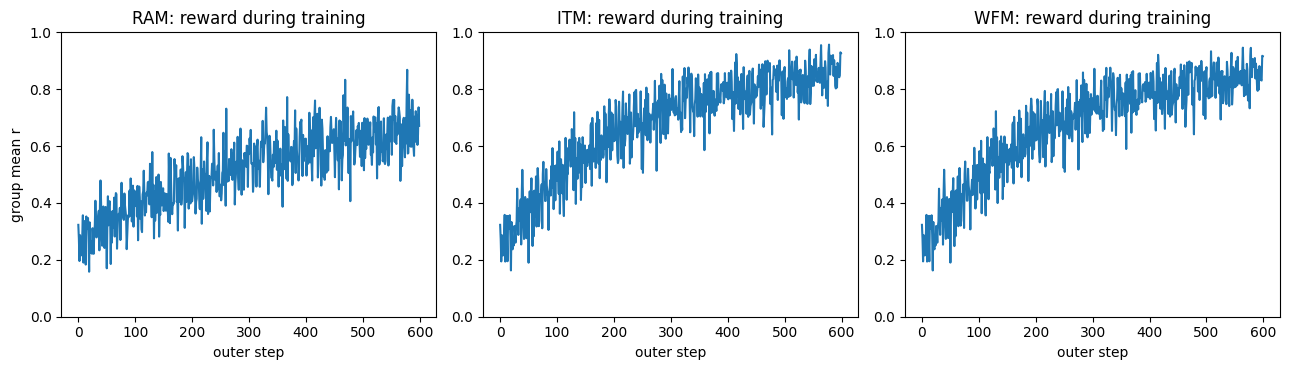

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, hist, title in zip(
    axes,
    [ram_hist, itm_hist, wfm_hist],
    ["RAM", "ITM", "WFM"],
):
    ax.plot(hist["mean_reward"])
    ax.set_title(f"{title}: reward during training")
    ax.set_xlabel("outer step")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("group mean r")
plt.tight_layout()
plt.show()

### Did the models match the analytic tilted target?

Because this is a 2D toy, we can compare every trained sampler to the analytic
target distribution:

$$
p_{\mathrm{target}}(x)
\propto
p_{\mathrm{ref}}(x)e^{\beta r(x)}.
$$

We report two main metrics:

1. **Mean reward.** Average $r(x)$ over generated samples. Higher means the
   sampler moves toward the rewarded region, but this metric alone can hide
   over-concentration.
2. **Sliced Wasserstein distance.** This compares generated samples to target
   samples directly. We project both point clouds onto many random 1D lines,
   sort the projected values, compare the sorted lists, and average over
   projections. Lower is better.

Mean reward answers: "did we move toward reward?" Sliced Wasserstein answers:
"did we match the full target geometry?" It can notice both mode-probability
errors and within-mode shifts, such as a rewarded cluster moving too far toward
the reward bump.

Since our ITM implementation is a RAM-style educational reconstruction, not
official code, we should read these numbers as an ablation of training targets
rather than as a faithful reproduction of the paper's reported performance.

In [11]:
def model_density_from_samples(samples):
    def density(grid_pts):
        return normalize_density(kde_density(grid_pts, samples, h=0.16))
    return density


grid_pts, _, _ = make_grid(n_grid=75)


def mode_probs_from_labels(labels: torch.Tensor, weights: torch.Tensor | None = None, n_modes: int = 8):
    if weights is None:
        counts = torch.bincount(labels, minlength=n_modes).float()
    else:
        counts = torch.zeros(n_modes, dtype=weights.dtype, device=weights.device)
        counts.scatter_add_(0, labels, weights)
    probs = counts / (counts.sum() + 1e-12)
    return probs


def sample_target_from_ref_pool(n: int, *, beta: float = BETA, seed: int | None = None) -> torch.Tensor:
    weights = torch.exp(beta * reward(ref_big))
    probs = weights / weights.sum()
    gen = None if seed is None else torch.Generator(device=probs.device).manual_seed(seed)
    idx = torch.multinomial(probs, n, replacement=True, generator=gen)
    return ref_big[idx]


def sliced_wasserstein_distance(
    samples_a: torch.Tensor,
    samples_b: torch.Tensor,
    *,
    n_projections: int = 128,
    seed: int = 0,
) -> float:
    n = min(len(samples_a), len(samples_b))
    samples_a = samples_a[:n]
    samples_b = samples_b[:n]

    gen = torch.Generator(device=samples_a.device).manual_seed(seed)
    directions = torch.randn(n_projections, samples_a.shape[1], generator=gen, device=samples_a.device)
    directions = directions / directions.norm(dim=1, keepdim=True).clamp_min(1e-12)

    proj_a = samples_a @ directions.T
    proj_b = samples_b @ directions.T
    proj_a = torch.sort(proj_a, dim=0).values
    proj_b = torch.sort(proj_b, dim=0).values
    return torch.sqrt(((proj_a - proj_b) ** 2).mean()).item()


target_mode_labels = assign_ring_modes(ref_big)
target_mode_weights = torch.exp(tilted_reward(ref_big))
target_mode_probs = mode_probs_from_labels(target_mode_labels, target_mode_weights)
target_eval_samples = sample_target_from_ref_pool(3000, beta=BETA, seed=2026)


@torch.no_grad()
def evaluate_sampler(name: str, model: VelocityNet, n: int = 3000):
    samples = sample_flow(model, n)
    density_grid = model_density_from_samples(samples)(grid_pts)
    labels = assign_ring_modes(samples)
    mode_probs = mode_probs_from_labels(labels)
    mean_r = reward(samples).mean().item()
    sliced_w = sliced_wasserstein_distance(samples, target_eval_samples)
    return {
        "name": name,
        "samples": samples,
        "density": density_grid,
        "mode_probs": mode_probs,
        "mean_reward": mean_r,
        "sliced_w": sliced_w,
    }


evals = [
    evaluate_sampler("pretrained", v_ref),
    evaluate_sampler("RAM", ram_model),
    evaluate_sampler("ITM", itm_model),
    evaluate_sampler("WFM", wfm_model),
]

display_markdown_table(
    ["Method", "Mean reward ↑", "Sliced W ↓"],
    [
        [e["name"], f"{e['mean_reward']:.3f}", f"{e['sliced_w']:.4f}"]
        for e in evals
    ],
)

| Method | Mean reward ↑ | Sliced W ↓ |
| --- | --- | --- |
| pretrained | 0.262 | 3.4719 |
| RAM | 0.656 | 1.6998 |
| ITM | 0.862 | 0.7685 |
| WFM | 0.846 | 0.8054 |

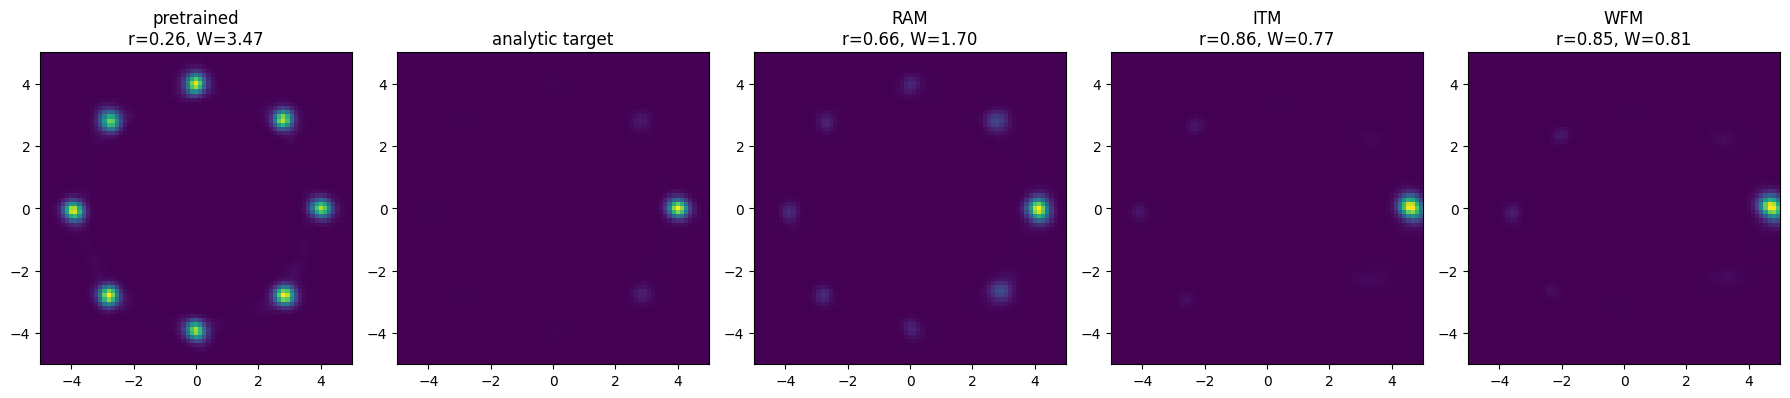

In [12]:
def density_from_grid_values(vals):
    def f(grid):
        # This closure assumes the same grid is used by plot_density.
        if len(grid) == len(vals):
            return vals
        return model_density_from_samples(torch.empty(0, 2))(grid)
    return f


fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
plot_density(
    p_ref_density,
    axes[0],
    title=f"pretrained\nr={evals[0]['mean_reward']:.2f}, W={evals[0]['sliced_w']:.2f}",
)
plot_density(p_target_density, axes[1], title="analytic target")
for ax, e in zip(axes[2:], evals[1:]):
    plot_density(
        model_density_from_samples(e["samples"]),
        ax,
        title=f"{e['name']}\nr={e['mean_reward']:.2f}, W={e['sliced_w']:.2f}",
    )
plt.tight_layout()
plt.show()

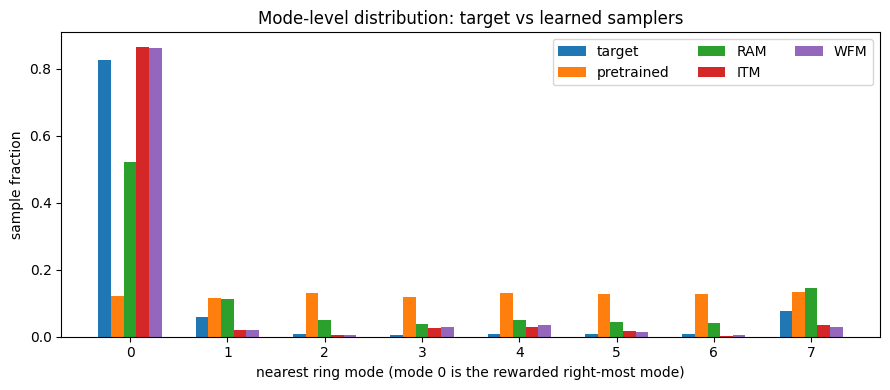

In [13]:
mode_names = [str(i) for i in range(8)]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(8)
mode_entries = [("target", target_mode_probs)] + [(e["name"], e["mode_probs"]) for e in evals]
width = 0.13
for offset, (name, probs) in zip(np.linspace(-2, 2, len(mode_entries)) * width, mode_entries):
    ax.bar(x + offset, probs.cpu().numpy(), width=width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(mode_names)
ax.set_xlabel("nearest ring mode (mode 0 is the rewarded right-most mode)")
ax.set_ylabel("sample fraction")
ax.set_title("Mode-level distribution: target vs learned samplers")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

**Findings:**

- **Pretrained** has low reward and large sliced Wasserstein distance, as
  expected. It still spreads mass around the original ring instead of preferring
  the rewarded side.
- **RAM** moves in the right direction: reward increases and sliced Wasserstein
  drops a lot. But the histogram shows that RAM is still conservative; it keeps
  more mass on non-rewarded modes than the target wants.
- **ITM** uses the full exponential coefficient, so it moves mass toward the
  rewarded side much more strongly. In this run, that also gives a much smaller
  sliced Wasserstein distance than RAM.
- **WFM** is surprisingly competitive on this tiny toy. Its sliced Wasserstein
  is close to ITM's, but remember that WFM is only a simple baseline here; the
  paper's main claim is not based on this toy setting.

The main takeaway is not "maximize reward as much as possible." The goal is to
match $p_{\text{target}}\propto p_{\text{ref}}e^{\beta r}$: reward should go
up, but the generated distribution should still look like the tilted reference
distribution in the density plots and the mode histogram.

## 7. Ablation: reward scale $\beta$

The cleanest ablation for the ITM-RAM connection is the reward scale $\beta$.
The two coefficients are:

$$
\text{RAM: }\beta r(X_0),
\qquad
\text{ITM: }e^{\beta r(X_0)}-1.
$$

When $\beta r$ is small, $e^{\beta r}-1\approx \beta r$, so RAM and ITM should
behave similarly. As $\beta$ grows, the higher-order terms in ITM matter more.

We use the same training budget as the main experiment and only change
$\beta$.

In [14]:
def evaluate_sampler_for_beta(
    name: str,
    model: VelocityNet,
    *,
    beta: float,
    n: int = 1500,
    seed: int = 0,
):
    torch.manual_seed(seed)
    samples = sample_flow(model, n)
    target_samples = sample_target_from_ref_pool(n, beta=beta, seed=seed + 123)
    return {
        "beta": beta,
        "method": name,
        "mean_reward": reward(samples).mean().item(),
        "sliced_w": sliced_wasserstein_distance(
            samples,
            target_samples,
            n_projections=64,
            seed=seed + 456,
        ),
    }


beta_values = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
methods = ["RAM", "ITM", "WFM"]
ablation_rows = []

for beta in beta_values:
    cfg_beta = RAMConfig(beta=beta)
    for method_id, method in enumerate(methods):
        torch.manual_seed(2000 + int(beta * 100) + method_id)
        if method == "RAM":
            model_beta, _ = train_ram(v_ref, v_ref, cfg=cfg_beta)
        else:
            model_beta, _ = train_tilt_matching(v_ref, v_ref, method=method.lower(), cfg=cfg_beta)
        row = evaluate_sampler_for_beta(
            method,
            model_beta,
            beta=beta,
            seed=3000 + int(beta * 100) + method_id,
        )
        ablation_rows.append(row)


def bold_if_winner(value: float, winner: float, *, digits: int):
    text = f"{value:.{digits}f}"
    return f"**{text}**" if abs(value - winner) < 1e-8 else text


reward_table_rows = []
w_table_rows = []
for beta in beta_values:
    rows = [row for row in ablation_rows if row["beta"] == beta]
    by_method = {row["method"]: row for row in rows}
    best_reward = max(row["mean_reward"] for row in rows)
    best_w = min(row["sliced_w"] for row in rows)
    reward_table_rows.append(
        [f"{beta:.1f}"]
        + [
            bold_if_winner(by_method[method]["mean_reward"], best_reward, digits=3)
            for method in methods
        ]
    )
    w_table_rows.append(
        [f"{beta:.1f}"]
        + [
            bold_if_winner(by_method[method]["sliced_w"], best_w, digits=4)
            for method in methods
        ]
    )

display(Markdown("**Mean reward ↑** (higher is better; winner in bold)"))
display_markdown_table(["β"] + methods, reward_table_rows)

display(Markdown("**Sliced Wasserstein ↓** (lower is better; winner in bold)"))
display_markdown_table(["β"] + methods, w_table_rows)

**Mean reward ↑** (higher is better; winner in bold)

| β | RAM | ITM | WFM |
| --- | --- | --- | --- |
| 0.5 | 0.322 | 0.337 | **0.492** |
| 1.0 | 0.394 | 0.482 | **0.661** |
| 2.0 | 0.497 | 0.750 | **0.753** |
| 3.0 | 0.579 | **0.842** | 0.818 |
| 4.0 | 0.604 | **0.853** | 0.840 |
| 5.0 | 0.670 | 0.859 | **0.888** |
| 6.0 | 0.694 | **0.893** | 0.856 |

**Sliced Wasserstein ↓** (lower is better; winner in bold)

| β | RAM | ITM | WFM |
| --- | --- | --- | --- |
| 0.5 | **0.3086** | 0.3306 | 1.3158 |
| 1.0 | **0.4162** | 0.7825 | 1.5711 |
| 2.0 | **0.4819** | 1.2453 | 2.2109 |
| 3.0 | 1.0586 | **0.9788** | 1.3154 |
| 4.0 | 1.3838 | **0.7651** | 0.8713 |
| 5.0 | 1.5516 | 0.8027 | **0.7511** |
| 6.0 | 1.8128 | **0.9320** | 1.1350 |

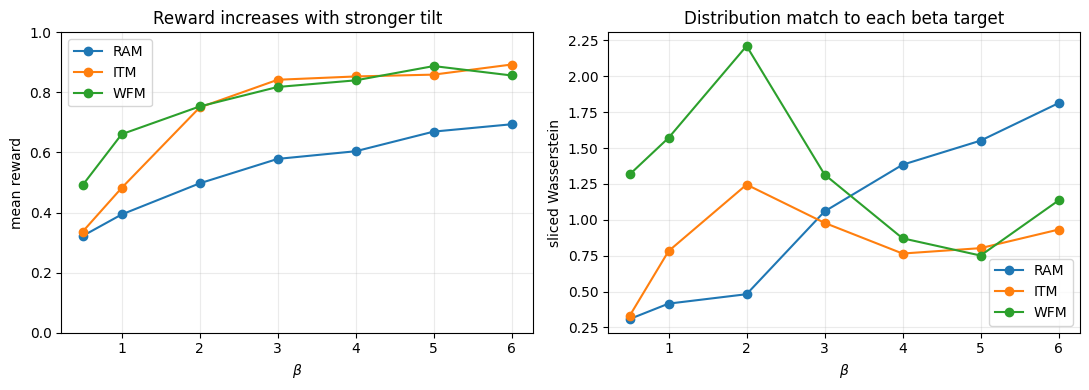

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for method in methods:
    rows = [r for r in ablation_rows if r["method"] == method]
    xs = [r["beta"] for r in rows]
    axes[0].plot(xs, [r["mean_reward"] for r in rows], marker="o", label=method)
    axes[1].plot(xs, [r["sliced_w"] for r in rows], marker="o", label=method)

axes[0].set_title("Reward increases with stronger tilt")
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel("mean reward")
axes[0].set_ylim(0, 1)

axes[1].set_title("Distribution match to each beta target")
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel("sliced Wasserstein")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Ablation reading:** The denser sweep shows that the conclusion is
$\beta$-dependent.

- For mild tilts ($\beta=0.5,1,2$), **RAM** has the best sliced Wasserstein.
  The target is only slightly different from the reference model, so the
  conservative first-order update is enough.
- For stronger tilts ($\beta=3,4,6$), **ITM** is best or close to best. This is
  where the full exponential coefficient starts to matter.
- **WFM** is genuinely competitive on this toy, and it even wins at $\beta=5$
  in this run. But it is also much worse at small $\beta$ and loses again at
  $\beta=6$, so the sweep does not show a clean "WFM is always better" story.

The useful lesson is that reward alone is misleading. WFM often gets high reward,
but sliced Wasserstein tells us whether that reward chasing still matches the
corresponding tilted target distribution.

## 8. Recap

**Implicit Tilt Matching (ITM)** learns to sample from reward-tilted distributions
using exponential reweighting:

$$
p_{\text{target}}(x) \propto p_{\text{ref}}(x) e^{\beta r(x)}.
$$

**Core idea:**

ITM keeps the full exponential tilt:

$$
T^{\text{ITM}}
=
v_{\text{ref}}
+
(e^{\beta r(X_0)}-1)
\left(
\varepsilon-X_0-\operatorname{sg}(v_\theta)
\right).
$$

RAM has the same structure but replaces $e^{\beta r(X_0)}-1$ by
$\beta r(X_0)$. So RAM is the first-order Taylor approximation of ITM.

**What the notebook demonstrated:**

* The bucket view gives a direct derivation of the ITM regression target.
* The ITM-RAM connection is just the Taylor expansion of $e^{\beta r}-1$.
* The same RAM-style training loop can run RAM, ITM, and WFM, which makes the
  comparison and ablations easy.
* Mean reward alone is not enough. We also need sliced Wasserstein distance to
  check whether samples match the full tilted target geometry.
* The $\beta$ sweep is nuanced: RAM can be best for mild tilts, ITM tends to
  become stronger for larger tilts, and WFM is genuinely competitive on this
  small toy but not consistently better.

We did not reproduce the paper's large-scale experiments such as Stable
Diffusion fine-tuning or molecular sampling. The goal here is narrower: make the
ITM target, its RAM connection, and its behavior on a simple 2D example easy to
understand.